<a href="https://colab.research.google.com/github/romariob10/AI/blob/main/USES_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Импорт необходимых библиотек
import os
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# Проверка, что данные для обучения не пусты
def check_data(df):
    if df.empty:
        raise ValueError("Данные пусты. Проверьте DataFrame.")
    for column in ['image', 'depth', 'mask']:
        if df[column].isnull().any():
            raise ValueError(f"Некоторые пути в столбце {column} содержат пустые значения.")
    print("Данные прошли проверку.")
    return True


In [ ]:
# Проверка данных
annotation_folder = "/dataset/"
if not os.path.exists(os.path.abspath(".") + annotation_folder):
    annotation_zip = tf.keras.utils.get_file(
        "val.tar.gz",
        cache_subdir=os.path.abspath("."),
        origin="http://diode-dataset.s3.amazonaws.com/val.tar.gz",
        extract=True,
    )

# Загрузка и подготовка данных
path = "/content/val_extracted/val/indoors"
filelist = []

for root, dirs, files in os.walk(path):
    for file in files:
        filelist.append(os.path.join(root, file))

filelist.sort()
data = {
    "image": [x for x in filelist if x.endswith(".png")],
    "depth": [x for x in filelist if x.endswith("_depth.npy")],
    "mask": [x for x in filelist if x.endswith("_depth_mask.npy")],
}
df = pd.DataFrame(data)

# Проверка данных
check_data(df)


Данные прошли проверку.


True

In [ ]:
# Генератор данных
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data, batch_size=6, dim=(768, 1024), n_channels=3, shuffle=True):
        self.data = data
        self.indices = self.data.index.tolist()
        self.dim = dim
        self.n_channels = n_channels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.min_depth = 0.1
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        if (index + 1) * self.batch_size > len(self.indices):
            self.batch_size = len(self.indices) - index * self.batch_size
        index = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        batch = [self.indices[k] for k in index]
        x, y = self.data_generation(batch)
        return x, y

    def on_epoch_end(self):
        self.index = np.arange(len(self.indices))
        if self.shuffle:
            np.random.shuffle(self.index)

    def load(self, image_path, depth_map, mask):
        image_ = cv2.imread(image_path)
        image_ = cv2.cvtColor(image_, cv2.COLOR_BGR2RGB)
        image_ = cv2.resize(image_, self.dim)
        image_ = tf.image.convert_image_dtype(image_, tf.float32)

        depth_map = np.load(depth_map).squeeze()
        mask = np.load(mask)
        mask = mask > 0

        max_depth = min(300, np.percentile(depth_map, 99))
        depth_map = np.clip(depth_map, self.min_depth, max_depth)
        depth_map = np.log(depth_map, where=mask)
        depth_map = np.ma.masked_where(~mask, depth_map)
        depth_map = np.clip(depth_map, 0.1, np.log(max_depth))
        depth_map = cv2.resize(depth_map, self.dim)
        depth_map = np.expand_dims(depth_map, axis=2)
        depth_map = tf.image.convert_image_dtype(depth_map, tf.float32)
        return image_, depth_map

    def data_generation(self, batch):
        x = np.empty((self.batch_size, *self.dim, self.n_channels))
        y = np.empty((self.batch_size, *self.dim, 1))
        for i, batch_id in enumerate(batch):
            x[i], y[i] = self.load(
                self.data["image"][batch_id],
                self.data["depth"][batch_id],
                self.data["mask"][batch_id],
            )
        x, y = x.astype("float32"), y.astype("float32")
        return x, y


In [ ]:
# Определение DownscaleBlock
class DownscaleBlock(tf.keras.layers.Layer):
    def __init__(self, filters):
        super().__init__()
        self.conv1 = layers.Conv2D(filters, (3, 3), strides=(2, 2), padding="same")
        self.conv2 = layers.Conv2D(filters, (3, 3), padding="same")
        self.activation = layers.ReLU()

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.activation(x)
        x = self.conv2(x)
        return x, x

# Определение BottleNeckBlock
class BottleNeckBlock(tf.keras.layers.Layer):
    def __init__(self, filters):
        super().__init__()
        self.conv1 = layers.Conv2D(filters, (3, 3), padding="same")
        self.conv2 = layers.Conv2D(filters, (3, 3), padding="same")
        self.activation = layers.ReLU()

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.activation(x)
        x = self.conv2(x)
        return x

# Определение UpscaleBlock с изменением размера для skip_connection
class UpscaleBlock(tf.keras.layers.Layer):
    def __init__(self, filters):
        super().__init__()
        self.upconv = layers.Conv2DTranspose(filters, (3, 3), strides=(2, 2), padding="same")
        self.conv = layers.Conv2D(filters, (3, 3), padding="same")
        self.skip_conv = layers.Conv2D(filters, (1, 1), padding="same")  # Для изменения размера пропуска
        self.upsample = layers.UpSampling2D(size=(2, 2), interpolation="bilinear")  # Масштабирование пропуска
        self.activation = layers.ReLU()

    def call(self, inputs, skip_connection):
        x = self.upconv(inputs)
        x = self.activation(x)

        # Масштабируем пропуск до нужного размера
        skip_connection = self.upsample(skip_connection)
        skip_connection = self.skip_conv(skip_connection)

        x = layers.concatenate([x, skip_connection])
        x = self.conv(x)
        x = self.activation(x)
        return x


In [ ]:
# Создание модели
class DepthEstimationModel(Model):
    def __init__(self):
        super().__init__()
        self.ssim_loss_weight = 0.85
        self.l1_loss_weight = 0.1
        self.edge_loss_weight = 0.9
        self.loss_metric = tf.keras.metrics.Mean(name="loss")
        f = [16, 32, 64, 128, 256]
        self.downscale_blocks = [
            DownscaleBlock(f[0]),
            DownscaleBlock(f[1]),
            DownscaleBlock(f[2]),
            DownscaleBlock(f[3]),
        ]
        self.bottle_neck_block = BottleNeckBlock(f[4])
        self.upscale_blocks = [
            UpscaleBlock(f[3]),
            UpscaleBlock(f[2]),
            UpscaleBlock(f[1]),
            UpscaleBlock(f[0]),
        ]
        self.conv_layer = layers.Conv2D(1, (1, 1), padding="same", activation="tanh")

    def call(self, x):
        c1, p1 = self.downscale_blocks[0](x)
        c2, p2 = self.downscale_blocks[1](p1)
        c3, p3 = self.downscale_blocks[2](p2)
        c4, p4 = self.downscale_blocks[3](p3)
        bn = self.bottle_neck_block(p4)
        u1 = self.upscale_blocks[0](bn, c4)
        u2 = self.upscale_blocks[1](u1, c3)
        u3 = self.upscale_blocks[2](u2, c2)
        u4 = self.upscale_blocks[3](u3, c1)
        return self.conv_layer(u4)


In [ ]:
# Подготовка данных для тренировки
train_loader = DataGenerator(
    data=df[:260].reset_index(drop=True), batch_size=32, dim=(256, 256)
)
validation_loader = DataGenerator(
    data=df[260:].reset_index(drop=True), batch_size=32, dim=(256, 256)
)


In [ ]:
# Обучение модели
optimizer = tf.keras.optimizers.SGD(learning_rate=0.00001, nesterov=False)
model = DepthEstimationModel()
model.compile(optimizer=optimizer, loss='mean_squared_error')  # Добавление функции потерь

model.fit(
    train_loader,
    epochs=30,
    validation_data=validation_loader,
)


In [67]:
def save_model(model, model_name="depth_estimation_model"):
    model.save(f"{model_name}.h5")
    print(f"Модель сохранена как {model_name}.h5")

save_model(model)

Модель сохранена как depth_estimation_model.h5


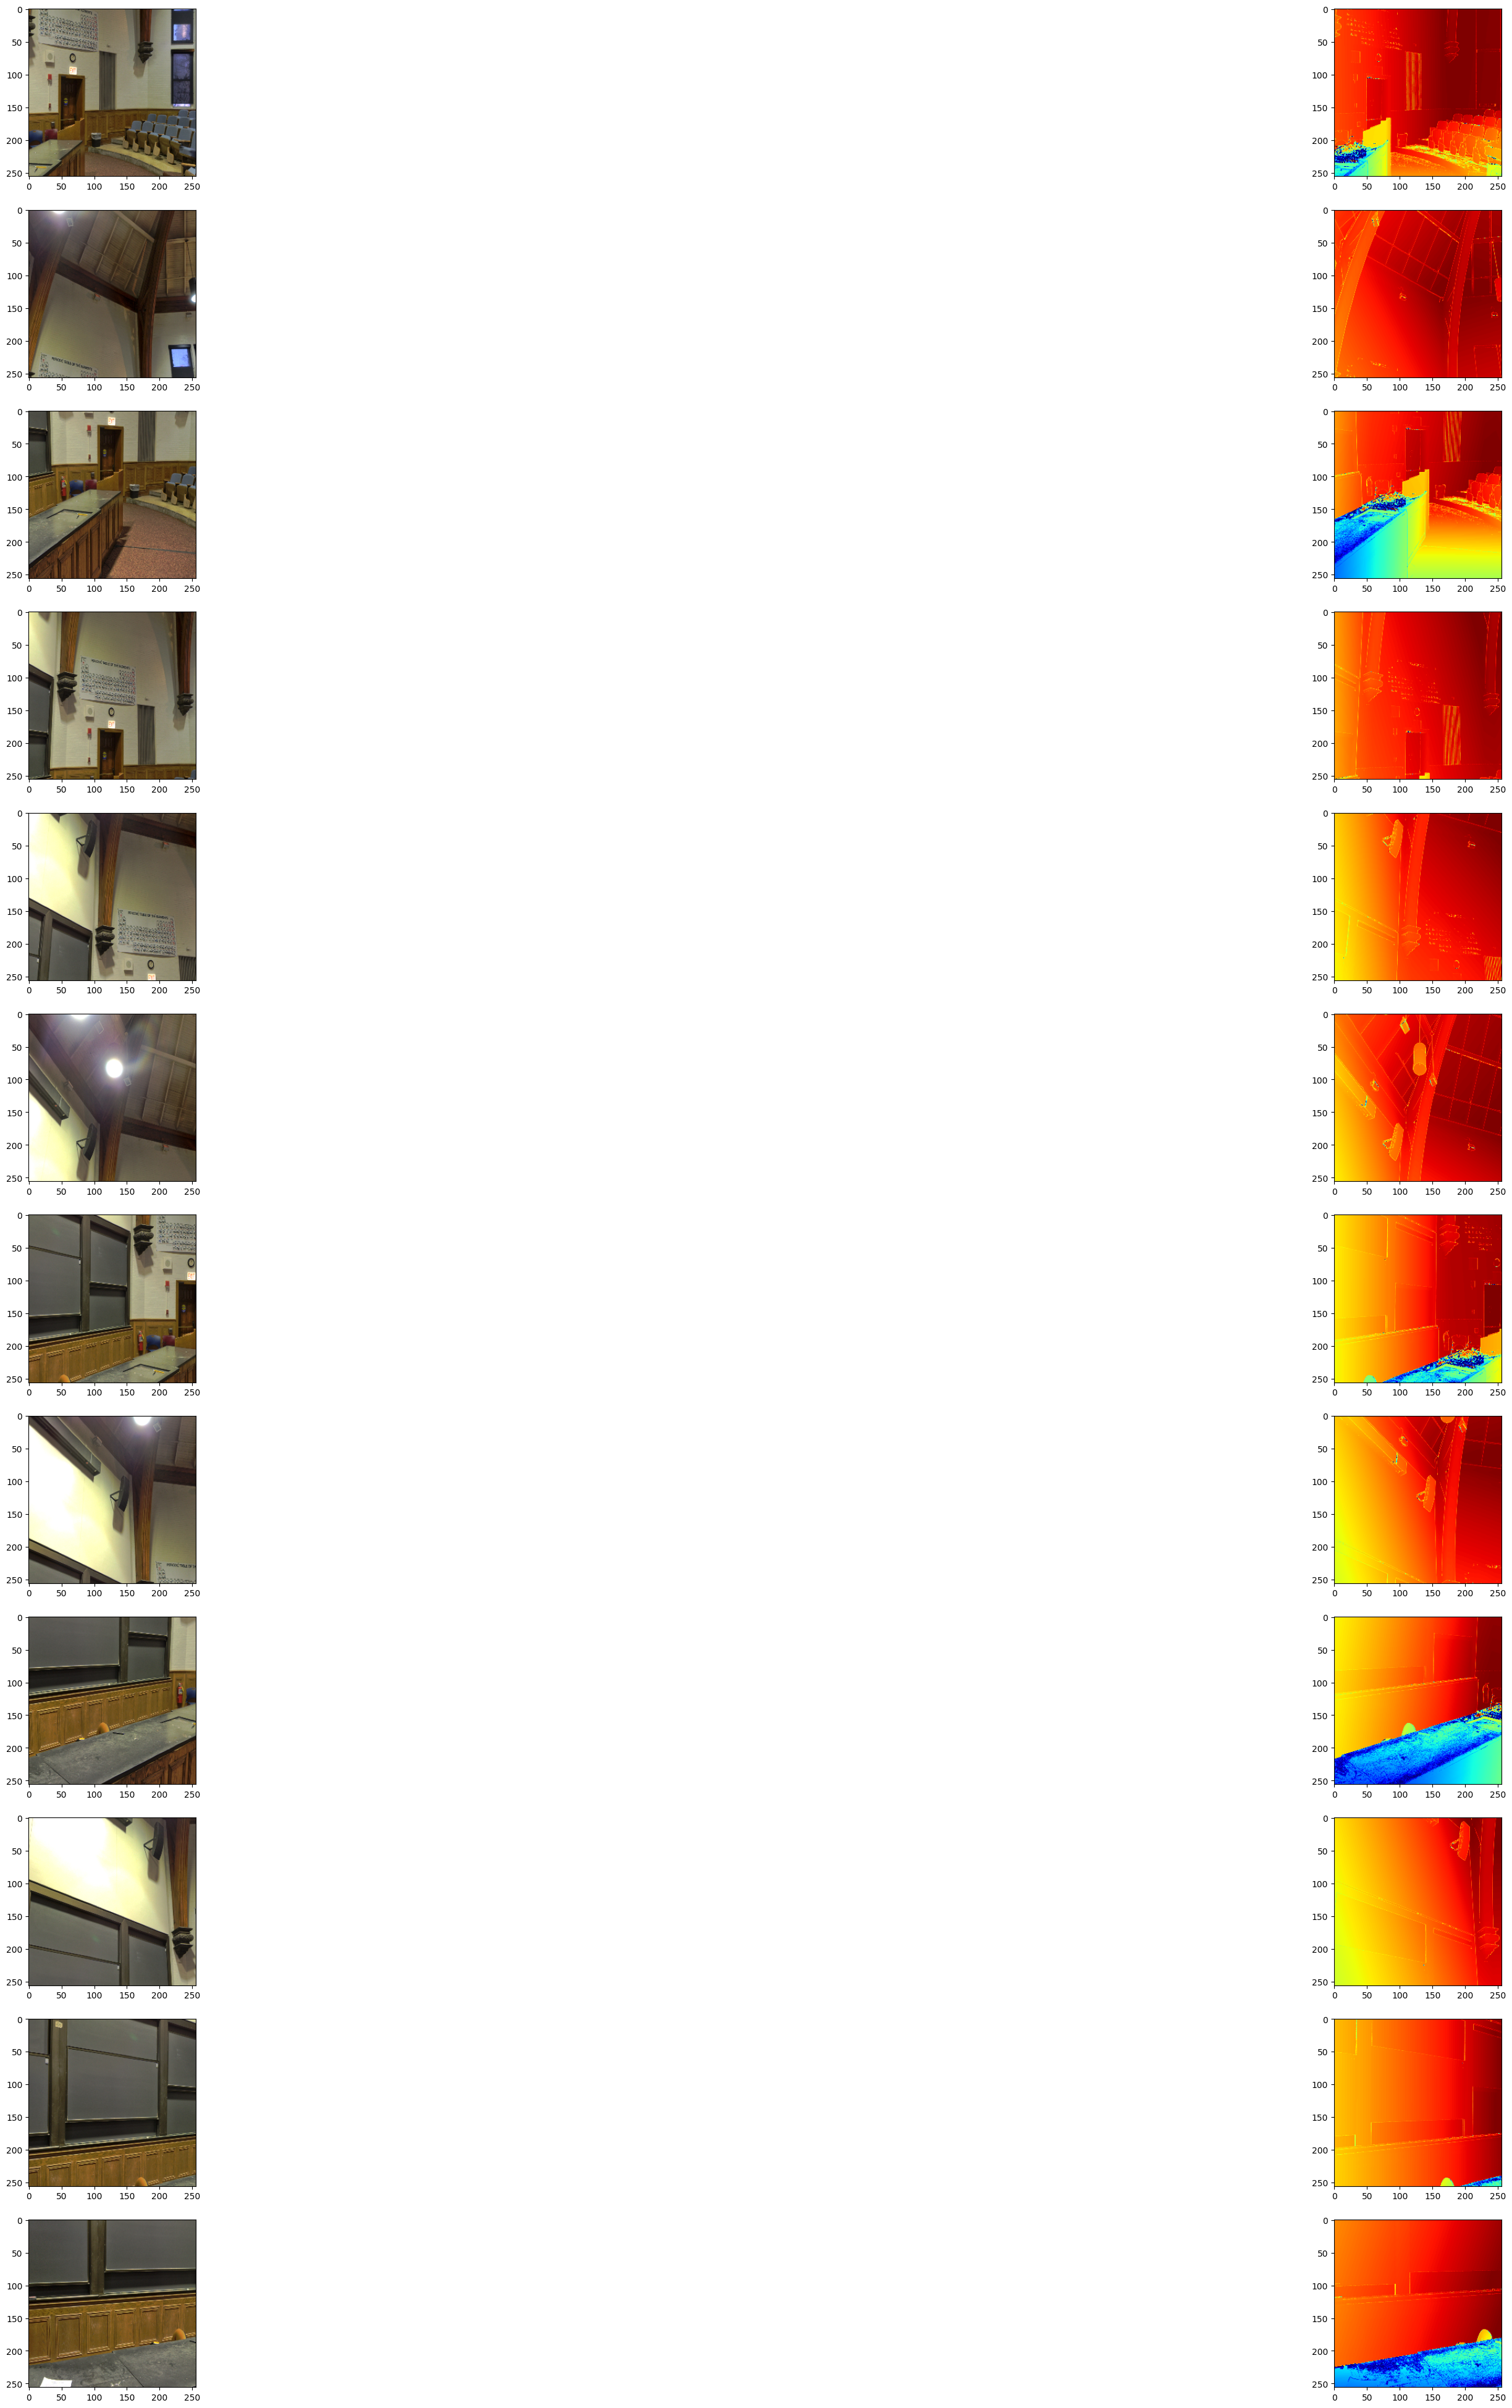

In [68]:
# Визуализация результатов
def visualize_depth_map(samples, size=12, test=False, model=None):
    input, target = samples
    cmap = plt.cm.jet
    cmap.set_bad(color="black")

    if test:
        pred = model.predict(input)
        fig, ax = plt.subplots(size, 3, figsize=(50, 50))
        for i in range(size):
            ax[i, 0].imshow((input[i].squeeze()))
            ax[i, 1].imshow((target[i].squeeze()), cmap=cmap)
            ax[i, 2].imshow((pred[i].squeeze()), cmap=cmap)
    else:
        fig, ax = plt.subplots(size, 2, figsize=(50, 50))
        for i in range(size):
            ax[i, 0].imshow((input[i].squeeze()))
            ax[i, 1].imshow((target[i].squeeze()), cmap=cmap)

# Визуализация на валидационных данных
size = 12
visualize_samples = next(
    iter(DataGenerator(data=df, batch_size=size, dim=(256, 256)))
)
visualize_depth_map(visualize_samples, size=size)
